# 04 — Dataset, DataLoader & Train/Val/Test Split

Build the PyTorch `Dataset` and PyTorch Lightning `DataModule` that feed the model in Notebook 05.

### Design decisions

**File-level split.** The split is done on `file_id` (original recording), not on individual segments. Two 5-second clips from the same source file must never end up in different splits — that would inflate test accuracy artificially.

**Source-aware stratification.** Stratification is by both `label` and `source_db`, so every split contains clips from every database. This prevents the model from learning database-specific recording artifacts as shortcuts.

**Switchable feature type.** A single `FEATURE_TYPE` flag (`'logmel'` or `'pcen'`) switches which `.npy` files are loaded. Nothing else changes.

**Training-set normalisation.** Mean and std are computed on the training set only, then applied identically to val and test. This prevents any test-set information from leaking into the normalisation statistics.

### Split ratios

```
Train : 70%
Val   : 15%   # early stopping and hyperparameter tuning
Test  : 15%   # touched only at the very end
```


## 0. Imports & configuration


In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT          = Path("data")
MANIFEST_CSV  = ROOT / "features_manifest.csv"

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
IDX2CLASS = {v: k for k, v in CLASS2IDX.items()}
CLASSES   = list(CLASS2IDX.keys())
N_CLASSES = len(CLASSES)

# ── Feature config ────────────────────────────────────────────────────────────
# Switch between 'logmel' and 'pcen' here — nothing else needs to change.
FEATURE_TYPE = 'logmel'   # or 'pcen'

# ── Spectrogram shape (must match Notebook 03) ────────────────────────────────
N_MELS    = 64
T_FRAMES  = 216

# ── DataLoader config ─────────────────────────────────────────────────────────
BATCH_SIZE   = 32
NUM_WORKERS  = 0    # keep at 0 on Windows (multiprocessing issues with notebooks)

print(f"Feature type : {FEATURE_TYPE}")
print(f"Input shape  : (1, {N_MELS}, {T_FRAMES})  [channels, mels, time]")
print(f"Batch size   : {BATCH_SIZE}")

Feature type : logmel
Input shape  : (1, 64, 216)  [channels, mels, time]
Batch size   : 32


---
## 1. Load & inspect manifest


In [4]:
manifest = pd.read_csv(MANIFEST_CSV)

# Normalise paths to current OS (handles Windows \ vs Linux /)
for col in ['logmel_path', 'pcen_path', 'out_path', 'source_path']:
    manifest[col] = manifest[col].apply(lambda p: str(Path(p)))

print(f"Total clips  : {len(manifest)}")
print(f"Unique file_ids : {manifest['file_id'].nunique()}")
print(f"Source databases: {sorted(manifest['source_db'].unique())}")
print()
print(manifest.groupby(['label', 'source_db']).size().unstack(fill_value=0))

Total clips  : 8125
Unique file_ids : 8125
Source databases: ['IDMT', 'MelBG', 'MelVeh', 'US8K']

source_db     IDMT  MelBG  MelVeh  US8K
label                                  
BG             575    409      16     0
Bus            106      0     265     0
Car            470      0     530     0
Construction     0      0       0  1000
Dog              0      0       0  1000
Horn             0      0       0   429
MC             430      0     248     0
Siren            0      0       0   929
Tram             0      0     718     0
Truck          783      0     217     0


---
## 2. Train / val / test split

Split at the file_id level to avoid leakage:
1. Get unique `(file_id, label, source_db)` triplets
2. Split file_ids into train 70% / val+test 30%, stratified by label
3. Split val+test into val 50% / test 50%, stratified by label
4. Map splits back to individual clip rows


In [5]:
# ── Step 1: unique file_ids with their label and source ───────────────────────
# Each file_id belongs to exactly one label and one source_db
file_meta = (
    manifest[['file_id', 'label', 'source_db']]
    .drop_duplicates(subset='file_id')
    .reset_index(drop=True)
)
print(f"Unique file_ids: {len(file_meta)}")

# Stratification key: label + source_db combined
# This ensures both are represented in every split
file_meta['strat_key'] = file_meta['label'] + '_' + file_meta['source_db']

# Drop strat keys with < 2 samples (can't split them)
key_counts = file_meta['strat_key'].value_counts()
rare_keys  = key_counts[key_counts < 3].index
if len(rare_keys):
    print(f"WARNING:  {len(rare_keys)} rare strat keys (< 3 files) -- falling back to label-only stratification for those")
    file_meta.loc[file_meta['strat_key'].isin(rare_keys), 'strat_key'] = \
        file_meta.loc[file_meta['strat_key'].isin(rare_keys), 'label']

Unique file_ids: 8125


In [6]:
# ── Step 2: train vs (val + test) ────────────────────────────────────────────
train_files, valtest_files = train_test_split(
    file_meta,
    test_size=0.30,
    stratify=file_meta['strat_key'],
    random_state=SEED
)

# ── Step 3: val vs test ───────────────────────────────────────────────────────
val_files, test_files = train_test_split(
    valtest_files,
    test_size=0.50,
    stratify=valtest_files['strat_key'],
    random_state=SEED
)

print(f"File-level split:")
print(f"  Train : {len(train_files):>5} file_ids")
print(f"  Val   : {len(val_files):>5} file_ids")
print(f"  Test  : {len(test_files):>5} file_ids")

File-level split:
  Train :  5687 file_ids
  Val   :  1219 file_ids
  Test  :  1219 file_ids


In [7]:
# ── Step 4: map back to clip rows ─────────────────────────────────────────────
train_ids = set(train_files['file_id'])
val_ids   = set(val_files['file_id'])
test_ids  = set(test_files['file_id'])

manifest['split'] = manifest['file_id'].map(
    lambda fid: 'train' if fid in train_ids else
                'val'   if fid in val_ids   else
                'test'
)

split_counts = manifest['split'].value_counts()
total        = len(manifest)
print("Clip-level split:")
for s in ['train', 'val', 'test']:
    n = split_counts[s]
    print(f"  {s:<6}: {n:>5} clips  ({100*n/total:.1f}%)")

# Verify zero overlap between splits at file level
assert len(train_ids & val_ids)  == 0, "Leakage: train intersect val"
assert len(train_ids & test_ids) == 0, "Leakage: train intersect test"
assert len(val_ids   & test_ids) == 0, "Leakage: val intersect test"
print("\nOK: No file-level leakage between splits")

Clip-level split:
  train :  5687 clips  (70.0%)
  val   :  1219 clips  (15.0%)
  test  :  1219 clips  (15.0%)

OK: No file-level leakage between splits


In [8]:
# Save updated manifest with split column
manifest.to_csv(MANIFEST_CSV, index=False)
print(f"Manifest updated with 'split' column -> {MANIFEST_CSV}")

Manifest updated with 'split' column -> data\features_manifest.csv


### 2a. Split visualisation


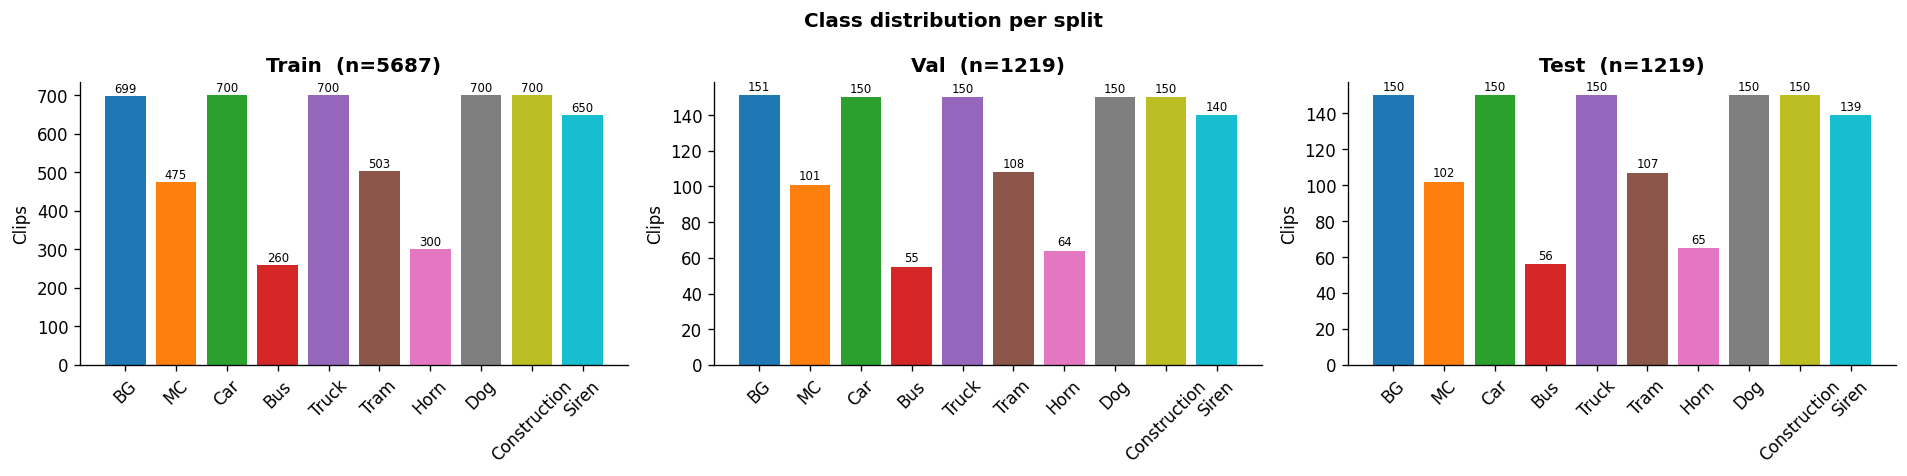

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Class distribution per split', fontweight='bold')
colors = plt.cm.tab10.colors
split_colors = {'train': 'steelblue', 'val': 'coral', 'test': 'mediumseagreen'}

for ax, split in zip(axes, ['train', 'val', 'test']):
    sub    = manifest[manifest['split'] == split]
    counts = sub['label'].value_counts().reindex(CLASSES, fill_value=0)
    bars   = ax.bar(counts.index, counts.values,
                    color=[colors[CLASS2IDX[c]] for c in counts.index])
    ax.set_title(f"{split.capitalize()}  (n={len(sub)})", fontweight='bold')
    ax.set_ylabel('Clips')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('04_split_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Normalisation statistics

Global mean and std are computed across all training-set spectrograms using Welford's online algorithm. Loading all spectrograms at once would require ~300 MB of RAM; the online method uses constant memory. Statistics are saved to `norm_stats_{feature_type}.npz`.


In [10]:
feat_col   = f'{FEATURE_TYPE}_path'
train_rows = manifest[manifest['split'] == 'train']

print(f"Computing normalisation stats on {len(train_rows)} training spectrograms...")

# ── Welford online mean/variance ──────────────────────────────────────────────
n      = 0
mean   = np.zeros((N_MELS, T_FRAMES), dtype=np.float64)
M2     = np.zeros((N_MELS, T_FRAMES), dtype=np.float64)

for _, row in train_rows.iterrows():
    x      = np.load(row[feat_col]).astype(np.float64)
    n     += 1
    delta  = x - mean
    mean  += delta / n
    M2    += delta * (x - mean)

std = np.sqrt(M2 / (n - 1)).astype(np.float32)
mean = mean.astype(np.float32)

# ── Save stats ────────────────────────────────────────────────────────────────
stats_path = ROOT / f"norm_stats_{FEATURE_TYPE}.npz"
np.savez(stats_path, mean=mean, std=std)

print(f"OK: Stats computed on {n} clips")
print(f"   mean range : [{mean.min():.3f}, {mean.max():.3f}]")
print(f"   std  range : [{std.min():.3f},  {std.max():.3f}]")
print(f"   Saved -> {stats_path}")

Computing normalisation stats on 5687 training spectrograms...
OK: Stats computed on 5687 clips
   mean range : [-79.543, -16.473]
   std  range : [2.376,  27.269]
   Saved -> data\norm_stats_logmel.npz


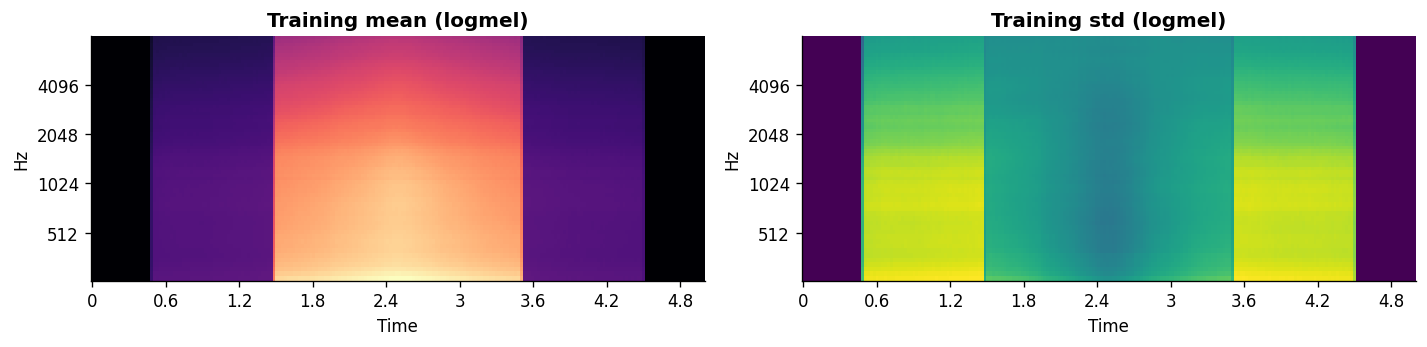

In [11]:
# Visualise mean and std spectrograms
import librosa.display

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
SR, HOP_LENGTH = 22050, 512

librosa.display.specshow(mean, sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel', fmin=50, fmax=8000,
                         ax=axes[0], cmap='magma')
axes[0].set_title(f'Training mean ({FEATURE_TYPE})', fontweight='bold')

librosa.display.specshow(std, sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel', fmin=50, fmax=8000,
                         ax=axes[1], cmap='viridis')
axes[1].set_title(f'Training std ({FEATURE_TYPE})', fontweight='bold')

plt.tight_layout()
plt.savefig('04_norm_stats.png', bbox_inches='tight')
plt.show()

---
## 4. PyTorch Dataset

`AudioDataset` loads a pre-computed `.npy` spectrogram, applies z-score normalisation, and optionally applies SpecAugment (time masking and frequency masking) on training data. It returns a tensor of shape `(1, N_MELS, T_FRAMES)` — the channel dimension expected by a 2D CNN.


In [12]:
class AudioDataset(Dataset):
    """
    Loads pre-computed spectrograms from disk.

    Args:
        df           : DataFrame rows for this split (must have feat_col and 'label_idx')
        feat_col     : Column name pointing to the .npy file ('logmel_path' or 'pcen_path')
        mean         : Training mean spectrogram, shape (N_MELS, T_FRAMES)
        std          : Training std spectrogram,  shape (N_MELS, T_FRAMES)
        augment      : Whether to apply SpecAugment (True for train only)
        time_mask_p  : Max time frames to mask in one SpecAugment block
        freq_mask_p  : Max mel bins to mask in one SpecAugment block
    """
    def __init__(
        self,
        df:          pd.DataFrame,
        feat_col:    str,
        mean:        np.ndarray,
        std:         np.ndarray,
        augment:     bool  = False,
        time_mask_p: int   = 30,
        freq_mask_p: int   = 10,
    ):
        self.paths      = df[feat_col].tolist()
        self.labels     = df['label_idx'].tolist()
        self.mean       = torch.from_numpy(mean).unsqueeze(0)   # (1, M, T)
        self.std        = torch.from_numpy(std).unsqueeze(0)    # (1, M, T)
        self.augment    = augment
        self.time_mask_p = time_mask_p
        self.freq_mask_p = freq_mask_p

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        x = np.load(self.paths[idx])                        # (M, T) float32
        x = torch.from_numpy(x).unsqueeze(0)               # (1, M, T)

        # Z-score normalisation
        x = (x - self.mean) / (self.std + 1e-6)

        # SpecAugment (training only)
        if self.augment:
            x = self._time_mask(x)
            x = self._freq_mask(x)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, label

    def _time_mask(self, x: torch.Tensor) -> torch.Tensor:
        """Zero out a random block of time frames."""
        _, _, T = x.shape
        t = torch.randint(0, self.time_mask_p, (1,)).item()
        t0 = torch.randint(0, max(1, T - t), (1,)).item()
        x[:, :, t0 : t0 + t] = 0.0
        return x

    def _freq_mask(self, x: torch.Tensor) -> torch.Tensor:
        """Zero out a random block of mel frequency bins."""
        _, M, _ = x.shape
        f = torch.randint(0, self.freq_mask_p, (1,)).item()
        f0 = torch.randint(0, max(1, M - f), (1,)).item()
        x[:, f0 : f0 + f, :] = 0.0
        return x

print("OK: AudioDataset defined")

OK: AudioDataset defined


---
## 5. PyTorch Lightning DataModule

`AudioDataModule` wraps the three splits into a single object. PyTorch Lightning calls `train_dataloader()`, `val_dataloader()`, and `test_dataloader()` automatically during training.


In [13]:
class AudioDataModule(pl.LightningDataModule):
    """
    PyTorch Lightning DataModule for the 10-class audio classifier.

    Args:
        manifest_csv  : Path to features_manifest.csv
        feature_type  : 'logmel' or 'pcen'
        stats_path    : Path to norm_stats_{feature_type}.npz
        batch_size    : Batch size for all loaders
        num_workers   : Workers for DataLoader (0 on Windows)
        augment_train : Whether to apply SpecAugment on training data
    """
    def __init__(
        self,
        manifest_csv:  str | Path,
        feature_type:  str   = 'logmel',
        stats_path:    str | Path | None = None,
        batch_size:    int   = 32,
        num_workers:   int   = 0,
        augment_train: bool  = True,
    ):
        super().__init__()
        self.manifest_csv  = Path(manifest_csv)
        self.feature_type  = feature_type
        self.feat_col      = f'{feature_type}_path'
        self.stats_path    = Path(stats_path) if stats_path else \
                             self.manifest_csv.parent / f'norm_stats_{feature_type}.npz'
        self.batch_size    = batch_size
        self.num_workers   = num_workers
        self.augment_train = augment_train

    def setup(self, stage: str | None = None):
        manifest = pd.read_csv(self.manifest_csv)
        # Normalise paths
        for col in [self.feat_col, 'out_path']:
            manifest[col] = manifest[col].apply(lambda p: str(Path(p)))

        # Load normalisation stats
        stats = np.load(self.stats_path)
        mean, std = stats['mean'], stats['std']

        self.train_ds = AudioDataset(
            manifest[manifest['split'] == 'train'].reset_index(drop=True),
            self.feat_col, mean, std, augment=self.augment_train
        )
        self.val_ds = AudioDataset(
            manifest[manifest['split'] == 'val'].reset_index(drop=True),
            self.feat_col, mean, std, augment=False
        )
        self.test_ds = AudioDataset(
            manifest[manifest['split'] == 'test'].reset_index(drop=True),
            self.feat_col, mean, std, augment=False
        )

        print(f"DataModule ready ({self.feature_type}):")
        print(f"  Train : {len(self.train_ds):>5} clips")
        print(f"  Val   : {len(self.val_ds):>5} clips")
        print(f"  Test  : {len(self.test_ds):>5} clips")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True,  num_workers=self.num_workers,
                          pin_memory=False)

    def val_dataloader(self):
        return DataLoader(self.val_ds,   batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers,
                          pin_memory=False)

    def test_dataloader(self):
        return DataLoader(self.test_ds,  batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers,
                          pin_memory=False)

print("OK: AudioDataModule defined")

OK: AudioDataModule defined


---
## 6. Sanity checks

### 6a. One batch per split


In [14]:
dm = AudioDataModule(
    manifest_csv  = MANIFEST_CSV,
    feature_type  = FEATURE_TYPE,
    batch_size    = BATCH_SIZE,
    num_workers   = NUM_WORKERS,
    augment_train = True,
)
dm.setup()

# Pull one batch from each loader
for split, loader in [('train', dm.train_dataloader()),
                       ('val',   dm.val_dataloader()),
                       ('test',  dm.test_dataloader())]:
    x, y = next(iter(loader))
    print(f"{split:6s} batch -- x: {tuple(x.shape)}  y: {tuple(y.shape)}  "
          f"x range: [{x.min():.2f}, {x.max():.2f}]")

DataModule ready (logmel):
  Train :  5687 clips
  Val   :  1219 clips
  Test  :  1219 clips
train  batch -- x: (32, 1, 64, 216)  y: (32,)  x range: [-3.49, 3.72]
val    batch -- x: (32, 1, 64, 216)  y: (32,)  x range: [-2.67, 4.54]
test   batch -- x: (32, 1, 64, 216)  y: (32,)  x range: [-4.34, 5.22]


### 6b. Normalised batch visualisation

Eight examples from the train loader. After normalisation, values should be centred around 0.


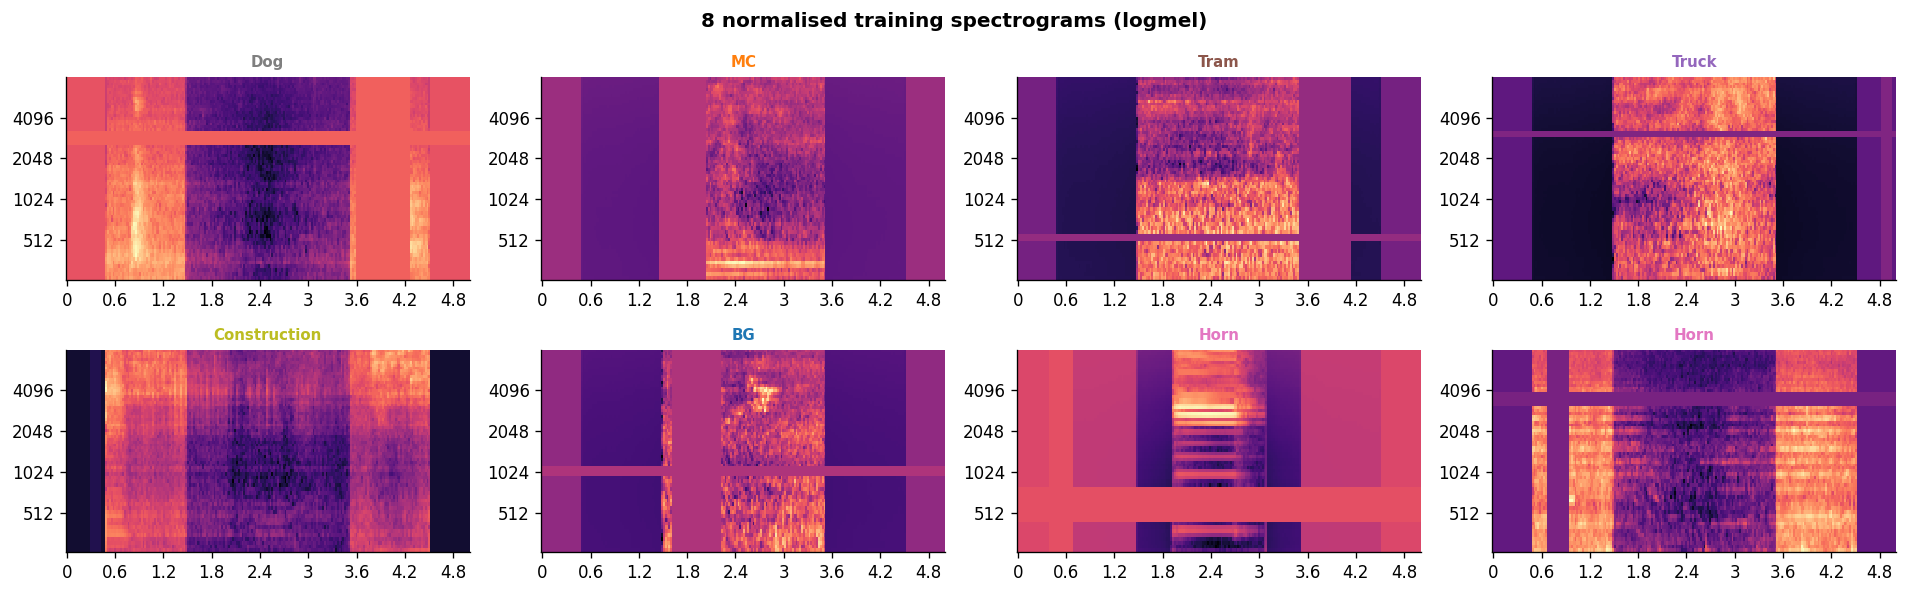

In [15]:
import librosa.display

x_batch, y_batch = next(iter(dm.train_dataloader()))

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle(f'8 normalised training spectrograms ({FEATURE_TYPE})', fontweight='bold')
axes = axes.flatten()

for i in range(8):
    spec  = x_batch[i, 0].numpy()   # (M, T)
    label = IDX2CLASS[y_batch[i].item()]
    librosa.display.specshow(spec, sr=22050, hop_length=512,
                             x_axis='time', y_axis='mel',
                             fmin=50, fmax=8000,
                             ax=axes[i], cmap='magma')
    axes[i].set_title(label, fontweight='bold', fontsize=9,
                      color=plt.cm.tab10.colors[CLASS2IDX[label]])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('04_train_batch_sample.png', bbox_inches='tight')
plt.show()

### 6c. SpecAugment check

Same spectrogram before and after augmentation — masked blocks should be visible.


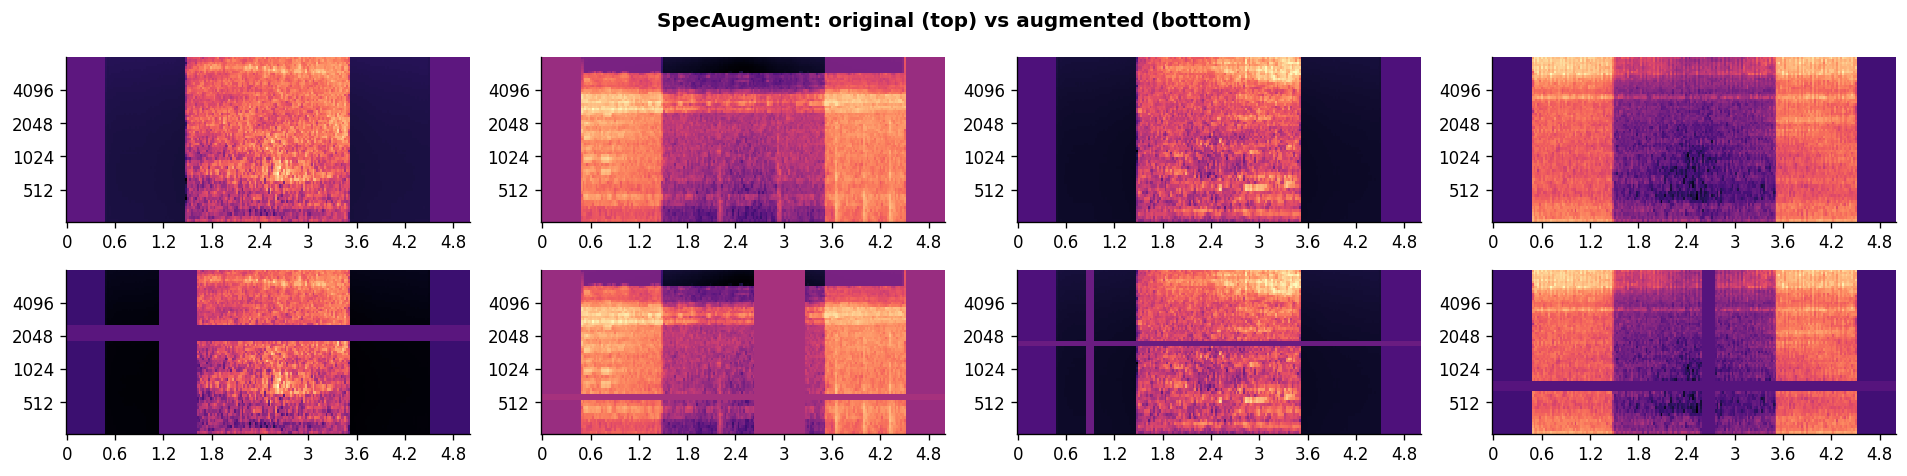

In [16]:
# Load one spectrogram without augmentation, then with
stats      = np.load(ROOT / f'norm_stats_{FEATURE_TYPE}.npz')
mean, std  = stats['mean'], stats['std']
train_df   = manifest[manifest['split'] == 'train'].reset_index(drop=True)
feat_col   = f'{FEATURE_TYPE}_path'

ds_no_aug  = AudioDataset(train_df.head(10), feat_col, mean, std, augment=False)
ds_aug     = AudioDataset(train_df.head(10), feat_col, mean, std, augment=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 4))
fig.suptitle('SpecAugment: original (top) vs augmented (bottom)', fontweight='bold')

for i in range(4):
    x_orig, _  = ds_no_aug[i]
    x_aug,  _  = ds_aug[i]

    librosa.display.specshow(x_orig[0].numpy(), sr=22050, hop_length=512,
                             x_axis='time', y_axis='mel', fmin=50, fmax=8000,
                             ax=axes[0, i], cmap='magma')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('')

    librosa.display.specshow(x_aug[0].numpy(), sr=22050, hop_length=512,
                             x_axis='time', y_axis='mel', fmin=50, fmax=8000,
                             ax=axes[1, i], cmap='magma')
    axes[1, i].set_xlabel('')
    axes[1, i].set_ylabel('')

plt.tight_layout()
plt.savefig('04_specaugment.png', bbox_inches='tight')
plt.show()

---
## 7. Summary


In [17]:
train_df = manifest[manifest['split'] == 'train']
val_df   = manifest[manifest['split'] == 'val']
test_df  = manifest[manifest['split'] == 'test']

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Split strategy : file-level (no leakage)")
print(f"  Feature type   : {FEATURE_TYPE}")
print(f"  Input shape    : (1, {N_MELS}, {T_FRAMES})")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  SpecAugment    : enabled on train")
print()
print(f"  {'Class':<15} {'Train':>7} {'Val':>7} {'Test':>7}")
print("  " + "-" * 38)
for cls in CLASSES:
    n_tr = (train_df['label'] == cls).sum()
    n_va = (val_df['label']   == cls).sum()
    n_te = (test_df['label']  == cls).sum()
    print(f"  {cls:<15} {n_tr:>7} {n_va:>7} {n_te:>7}")
print("  " + "-" * 38)
print(f"  {'TOTAL':<15} {len(train_df):>7} {len(val_df):>7} {len(test_df):>7}")
print()


DATASET SUMMARY
  Split strategy : file-level (no leakage)
  Feature type   : logmel
  Input shape    : (1, 64, 216)
  Batch size     : 32
  SpecAugment    : enabled on train

  Class             Train     Val    Test
  --------------------------------------
  BG                  699     151     150
  MC                  475     101     102
  Car                 700     150     150
  Bus                 260      55      56
  Truck               700     150     150
  Tram                503     108     107
  Horn                300      64      65
  Dog                 700     150     150
  Construction        700     150     150
  Siren               650     140     139
  --------------------------------------
  TOTAL              5687    1219    1219

